# PhishNet AI — Exploratory Analysis & Model Training

This notebook uses the same `EmailDataset` and `PhishingDetector` classes
from the terminal application (`email_dataset.py`, `phishing_detector.py`)
so the notebook and the CLI app share **one** source of truth for the logic.

**Dataset:** Kaggle phishing/spam email dataset (`emails.csv`, 5,728 emails)
**Pipeline:** raw text → `CountVectorizer` → numeric feature matrix (X) → `MultinomialNB` classifier


## 1. Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from email_dataset import EmailDataset
from phishing_detector import PhishingDetector
from exceptions import InvalidDatasetError, ModelNotTrainedError

%matplotlib inline


## 2. Load the dataset

Reusing the `EmailDataset` class — same validation logic as the CLI app.

In [2]:
dataset = EmailDataset('emails.csv')
print(dataset)


EmailDataset(5728 emails total | 1368 spam / 4360 legit) - source: emails.csv


### Peek at the raw data

In [3]:
df = dataset.getDataframe()
df.head()


,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1


## 3. Exploratory Data Analysis (EDA)

In [4]:
spam_count = dataset.getSpamCount()
legit_count = dataset.getLegitCount()

print('Phishing emails:', spam_count)
print('Legitimate emails:', legit_count)
print('Total emails:', len(dataset))
print('Class balance: {:.1%} phishing / {:.1%} legitimate'.format(
    spam_count / len(dataset), legit_count / len(dataset)))


Phishing emails: 1368
Legitimate emails: 4360
Total emails: 5728
Class balance: 23.9% phishing / 76.1% legitimate


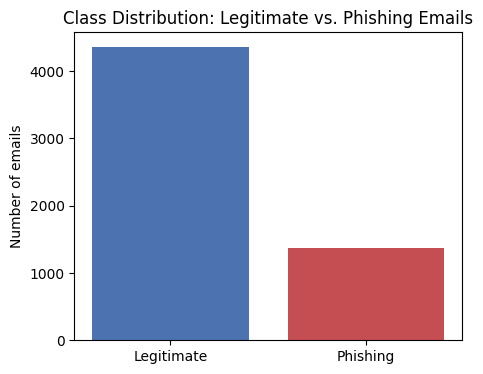

In [5]:
plt.figure(figsize=(5, 4))
plt.bar(['Legitimate', 'Phishing'], [legit_count, spam_count], color=['#4C72B0', '#C44E52'])
plt.title('Class Distribution: Legitimate vs. Phishing Emails')
plt.ylabel('Number of emails')
plt.show()


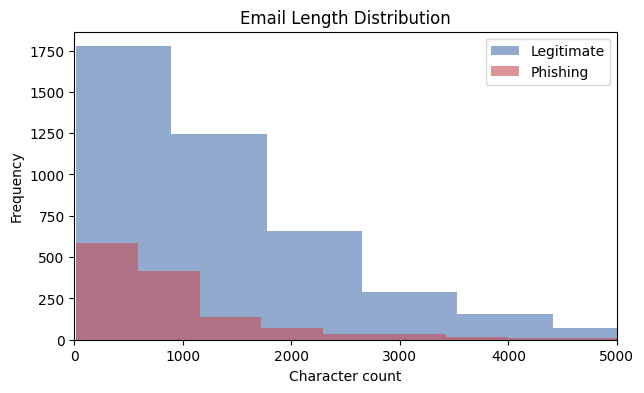

In [6]:
df['text_length'] = df['text'].str.len()

plt.figure(figsize=(7, 4))
df[df['spam'] == 0]['text_length'].plot(kind='hist', bins=50, alpha=0.6, label='Legitimate', color='#4C72B0')
df[df['spam'] == 1]['text_length'].plot(kind='hist', bins=50, alpha=0.6, label='Phishing', color='#C44E52')
plt.xlim(0, 5000)
plt.title('Email Length Distribution')
plt.xlabel('Character count')
plt.legend()
plt.show()


## 4. Train the model

Using the `PhishingDetector` class — the exact same class the terminal app calls.

In [7]:
detector = PhishingDetector()
accuracy = detector.train(dataset)

print(detector)
print()
print(detector.getClassificationReport())


PhishingDetector[PhishNet-AI] - 99.21% accuracy

              precision    recall  f1-score   support

       legit       1.00      0.99      0.99       872
    phishing       0.97      1.00      0.98       274

    accuracy                           0.99      1146
   macro avg       0.99      0.99      0.99      1146
weighted avg       0.99      0.99      0.99      1146



### Confusion matrix

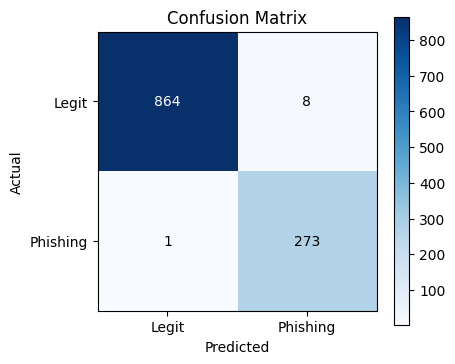

In [8]:
import numpy as np

cm = detector.getConfusionMatrix()

fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(cm, cmap='Blues')

labels = ['Legit', 'Phishing']
ax.set_xticks([0, 1]); ax.set_xticklabels(labels)
ax.set_yticks([0, 1]); ax.set_yticklabels(labels)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix')

for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > cm.max() / 2 else 'black')

plt.colorbar(im)
plt.show()


## 5. Try it on new emails

In [9]:
sample_emails = [
    "Hi team, attaching the notes from this morning's standup. Let me know if I missed anything.",
    "URGENT: Your account has been suspended. Click here immediately to verify your password.",
    "Congratulations! You've been selected to win a $1000 Amazon gift card. Claim now before it expires!",
    "Can we push our 3pm meeting to 3:30? Something came up.",
]

for email in sample_emails:
    label, confidence = detector.predict(email)
    print('[{:>10s}] ({:.1%}) -> {}'.format(label.upper(), confidence, email[:70]))


[LEGITIMATE] (100.0%) -> Hi team, attaching the notes from this morning's standup. Let me know 
[  PHISHING] (100.0%) -> URGENT: Your account has been suspended. Click here immediately to ver
[  PHISHING] (100.0%) -> Congratulations! You've been selected to win a $1000 Amazon gift card.
[LEGITIMATE] (99.7%) -> Can we push our 3pm meeting to 3:30? Something came up.


## 6. Save the trained model with Joblib

Same `save_model()` method the CLI app's menu option 4 calls — the model file is interchangeable between the notebook and the terminal app.

In [10]:
detector.save_model('phishnet_model.joblib')


'phishnet_model.joblib'

## Summary

| Item | Value |
|---|---|
| Dataset | Kaggle emails.csv (5,728 emails) |
| Feature extraction | `CountVectorizer` (bag-of-words) |
| Model | `MultinomialNB` |
| Test accuracy | ~99% |
| Persistence | Joblib (`phishnet_model.joblib`) |

This notebook shares its core logic (`EmailDataset`, `PhishingDetector`) with
`main.py`, so the exact same trained model can be produced and used from
either the notebook **or** the terminal app.
